Epoch 1: Train Acc=0.5447, Test Acc=0.7619
Epoch 2: Train Acc=0.8151, Test Acc=0.8030
Epoch 3: Train Acc=0.8405, Test Acc=0.8290
Epoch 4: Train Acc=0.8518, Test Acc=0.8372
Epoch 5: Train Acc=0.8611, Test Acc=0.8373
Epoch 6: Train Acc=0.8661, Test Acc=0.8363
Epoch 7: Train Acc=0.8719, Test Acc=0.8427
Epoch 8: Train Acc=0.8759, Test Acc=0.8448
Epoch 9: Train Acc=0.8806, Test Acc=0.8407
Epoch 10: Train Acc=0.8818, Test Acc=0.8498
Epoch 11: Train Acc=0.8846, Test Acc=0.8457
Epoch 12: Train Acc=0.8866, Test Acc=0.8480
Epoch 13: Train Acc=0.8884, Test Acc=0.8452
Epoch 14: Train Acc=0.8890, Test Acc=0.8417
Epoch 15: Train Acc=0.8915, Test Acc=0.8422
Epoch 16: Train Acc=0.8922, Test Acc=0.8514
Epoch 17: Train Acc=0.8937, Test Acc=0.8475
Epoch 18: Train Acc=0.8944, Test Acc=0.8497
Epoch 19: Train Acc=0.8971, Test Acc=0.8463
Epoch 20: Train Acc=0.8958, Test Acc=0.8454


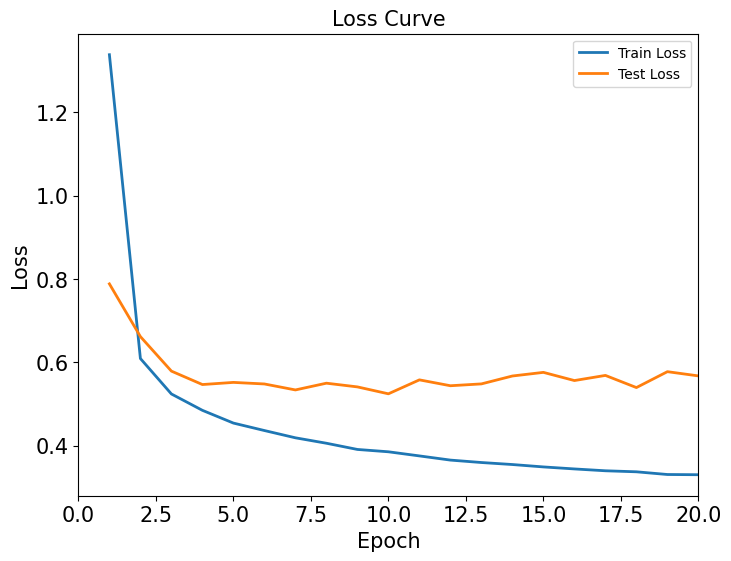

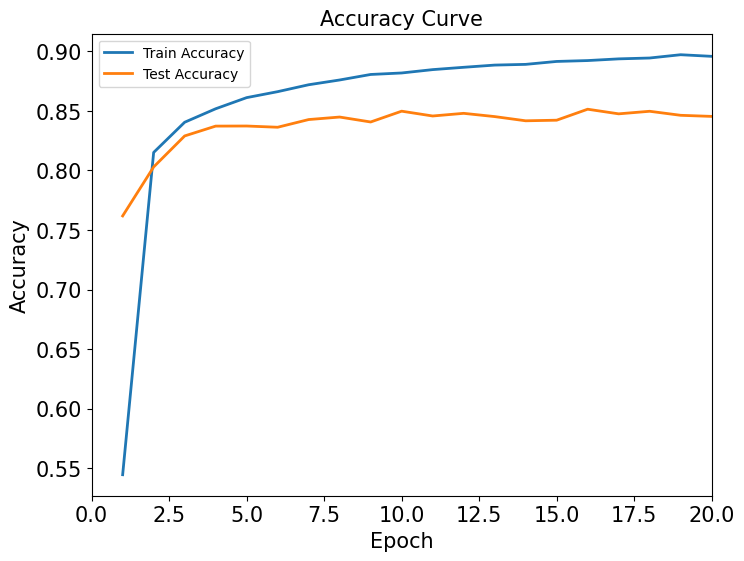

In [23]:
import scipy.io as sio
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# ======================
# 设备选择（GPU优先）
# ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ======================
# 构建数据集
# ======================
class SVHNDataset(Dataset):
    def __init__(self, mat_file):
        """
        读取 SVHN .mat 数据
        """
        data = sio.loadmat(mat_file)

        self.X = data['X']  # 原始图像数据 (32,32,3,N)
        self.y = data['y'].flatten() # 标签 (N, 1)

        # 标签处理：10 → 0（SVHN中标签10将其设置为0，保证在0~9之间）
        self.y[self.y == 10] = 0

        # 转换维度 → (N,3,32,32)，并归一化
        self.X = np.transpose(self.X, (3, 2, 0, 1)) / 255.0

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        """
        每次训练取一张图和标签
        """
        img = torch.tensor(self.X[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return img, label


# ======================
# 构建CNN模型
# ======================
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # 卷积层1：3 → 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        # 卷积层2：32 → 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # 池化层（降采样）
        self.pool = nn.MaxPool2d(2, 2)

        # 全连接层
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        """
        前向传播
        """
        # 卷积 + ReLU + 池化
        x = self.pool(F.relu(self.conv1(x)))  # 32x32 → 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 16x16 → 8x8

        # 展平
        x = x.view(x.size(0), -1)

        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


# ======================
# 数据加载
# ======================
train_dataset = SVHNDataset('train_32x32.mat')
test_dataset = SVHNDataset('test_32x32.mat')

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)


# ======================
# 初始化模型
# ======================
model = CNN().to(device)

# 损失函数（分类任务标准）
criterion = nn.CrossEntropyLoss()

# 优化器
optimizer = optim.Adam(model.parameters(), lr=0.005)


# ======================
# 记录指标
# ======================
train_losses = []
test_losses = []
train_accs = []
test_accs = []


# ======================
# 测试函数
# ======================
def evaluate(loader):
    """
    在测试集上评估模型
    """
    model.eval()  # 进入评估模式

    correct = 0
    total = 0
    loss_sum = 0

    with torch.no_grad():  # 不计算梯度（节省计算）
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            loss_sum += loss.item()

            # 预测类别
            _, pred = torch.max(outputs, 1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total


# ======================
# 训练过程
# ======================
epochs = 20

for epoch in range(epochs):
    model.train()  # 进入训练模式

    running_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        # 梯度清零
        optimizer.zero_grad()

        # 前向传播
        outputs = model(x)

        # 计算损失
        loss = criterion(outputs, y)

        # 反向传播
        loss.backward()

        # 更新参数
        optimizer.step()

        # 统计
        running_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    # 计算训练指标
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # 测试集评估
    test_loss, test_acc = evaluate(test_loader)

    # 记录
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # 输出
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")


# ======================
# 保存模型
# ======================
torch.save(model.state_dict(), "svhn_cnn.pth")


# ======================
# 可视化结果
# ======================

epochs_x = np.arange(1,epochs+1,1)
# Loss 曲线
plt.figure(figsize=(8,6))
plt.plot(epochs_x, train_losses, label='Train Loss',lw=2)
plt.plot(epochs_x, test_losses, label='Test Loss',lw=2)
plt.legend()
plt.title('Loss Curve', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Loss', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(0,epochs)
plt.savefig('Loss curve')
plt.show()

# Accuracy 曲线
plt.figure(figsize=(8,6))
plt.plot(epochs_x, train_accs, label='Train Accuracy',lw=2)
plt.plot(epochs_x, test_accs, label='Test Accuracy',lw=2)
plt.legend()
plt.title('Accuracy Curve', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(0,epochs)
plt.savefig('Accuracy curve')
plt.show()